In [10]:
import pandas as pd 

In [11]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Python\Pandas\dairy_dataset.csv")
df.head()

,Location,Total Land Area (acres),Number of Cows,Farm Size,Date,Product ID,Product Name,Brand,Quantity (liters/kg),Price per Unit,...,Production Date,Expiration Date,Quantity Sold (liters/kg),Price per Unit (sold),Approx. Total Revenue(INR),Customer Location,Sales Channel,Quantity in Stock (liters/kg),Minimum Stock Threshold (liters/kg),Reorder Quantity (liters/kg)
0,Telangana,310.84,96,Medium,2/17/2022,5,Ice Cream,Dodla Dairy,222.40,85.72,...,12/27/2021,1/21/2022,7,82.24,575.68,Madhya Pradesh,Wholesale,215,19.55,64.03
1,Uttar Pradesh,19.19,44,Large,12-01-2021,1,Milk,Amul,687.48,42.61,...,10-03-2021,10/25/2021,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
2,Tamil Nadu,581.69,24,Medium,2/28/2022,4,Yogurt,Dodla Dairy,503.48,36.50,...,1/14/2022,2/13/2022,256,33.81,8655.36,Madhya Pradesh,Online,247,15.10,140.83
3,Telangana,908.00,89,Small,06-09-2019,3,Cheese,Britannia Industries,823.36,26.52,...,5/15/2019,7/26/2019,601,28.92,17380.92,Rajasthan,Online,222,74.50,57.68
4,Maharashtra,861.95,21,Medium,12/14/2020,8,Buttermilk,Mother Dairy,147.77,83.85,...,10/17/2020,10/28/2020,145,83.07,12045.15,Jharkhand,Retail,2,76.02,33.40


In [12]:
#price per unit sold
#total land area
#number of cows 
#farm size
df.drop(columns="Location", inplace=True)

In [13]:
df.columns

Index(['Total Land Area (acres)', 'Number of Cows', 'Farm Size', 'Date',
       'Product ID', 'Product Name', 'Brand', 'Quantity (liters/kg)',
       'Price per Unit', 'Total Value', 'Shelf Life (days)',
       'Storage Condition', 'Production Date', 'Expiration Date',
       'Quantity Sold (liters/kg)', 'Price per Unit (sold)',
       'Approx. Total Revenue(INR)', 'Customer Location', 'Sales Channel',
       'Quantity in Stock (liters/kg)', 'Minimum Stock Threshold (liters/kg)',
       'Reorder Quantity (liters/kg)'],
      dtype='object')

In [14]:
df.drop(columns=["Minimum Stock Threshold (liters/kg)", "Expiration Date", "Production Date", "Reorder Quantity (liters/kg)"], inplace=True)

In [17]:
df.shape 

(4325, 17)

In [16]:
df.drop(columns="Quantity in Stock (liters/kg)", inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Land Area (acres)     4325 non-null   float64
 1   Number of Cows              4325 non-null   int64  
 2   Farm Size                   4325 non-null   object 
 3   Date                        4325 non-null   object 
 4   Product ID                  4325 non-null   int64  
 5   Product Name                4325 non-null   object 
 6   Brand                       4325 non-null   object 
 7   Quantity (liters/kg)        4325 non-null   float64
 8   Price per Unit              4325 non-null   float64
 9   Total Value                 4325 non-null   float64
 10  Shelf Life (days)           4325 non-null   int64  
 11  Storage Condition           4325 non-null   object 
 12  Quantity Sold (liters/kg)   4325 non-null   int64  
 13  Price per Unit (sold)       4325 

In [19]:
df.duplicated().sum()

np.int64(0)

In [41]:
import seaborn as sns 
import matplotlib.pyplot as plt 

In [21]:
df["Product Name"].unique()

array(['Ice Cream', 'Milk', 'Yogurt', 'Cheese', 'Buttermilk', 'Curd',
       'Paneer', 'Lassi', 'Ghee', 'Butter'], dtype=object)

In [23]:
df.groupby("Product Name")["Price per Unit (sold)"].max()

Product Name
Butter        104.15
Buttermilk    101.88
Cheese        102.71
Curd          102.30
Ghee          103.61
Ice Cream     100.68
Lassi         104.06
Milk          104.51
Paneer        103.57
Yogurt        103.89
Name: Price per Unit (sold), dtype: float64

Text(0.5, 1.0, 'Price per Unit (sold) by Product Name')

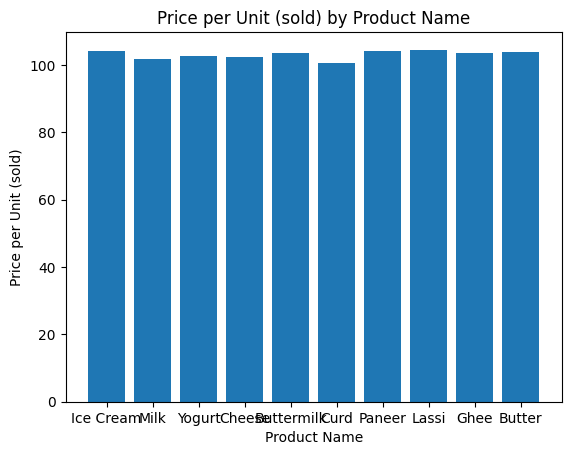

In [26]:
plt.bar(df["Product Name"].unique(), df.groupby("Product Name")["Price per Unit (sold)"].max())
plt.xlabel("Product Name")
plt.ylabel("Price per Unit (sold)")
plt.title("Price per Unit (sold) by Product Name")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Ice Cream'),
  Text(1, 0, 'Milk'),
  Text(2, 0, 'Yogurt'),
  Text(3, 0, 'Cheese'),
  Text(4, 0, 'Buttermilk'),
  Text(5, 0, 'Curd'),
  Text(6, 0, 'Paneer'),
  Text(7, 0, 'Lassi'),
  Text(8, 0, 'Ghee'),
  Text(9, 0, 'Butter')])

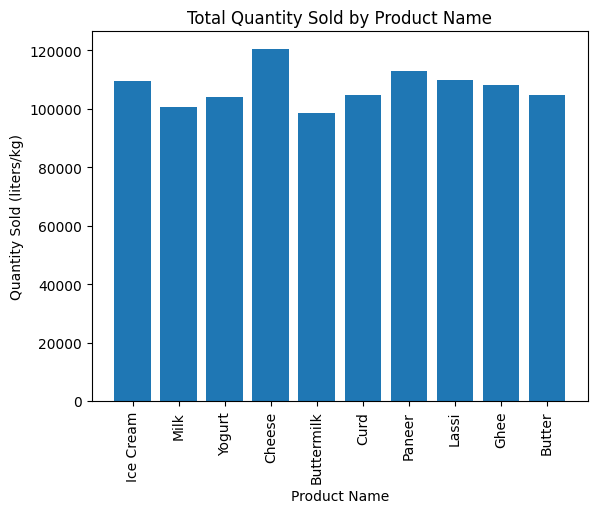

In [38]:
#Total quantity sold by Product Name
plt.bar(df["Product Name"].unique(), df.groupby("Product Name")["Quantity Sold (liters/kg)"].sum())
plt.xlabel("Product Name")
plt.ylabel("Quantity Sold (liters/kg)")
plt.title("Total Quantity Sold by Product Name")
plt.xticks(rotation=90)

In [29]:
#Total Quantity sold by brand name
df.groupby("Brand")["Quantity Sold (liters/kg)"].sum()

Brand
Amul                    264450
Britannia Industries     21047
Dodla Dairy              49667
Dynamix Dairies          26772
Mother Dairy            251745
Palle2patnam             51119
Parag Milk Foods         26762
Passion Cheese           27296
Raj                     174742
Sudha                   148917
Warana                   30494
Name: Quantity Sold (liters/kg), dtype: int64

In [30]:
df["Brand"].unique()

array(['Dodla Dairy', 'Amul', 'Britannia Industries', 'Mother Dairy',
       'Raj', 'Dynamix Dairies', 'Sudha', 'Passion Cheese', 'Warana',
       'Palle2patnam', 'Parag Milk Foods'], dtype=object)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Dodla Dairy'),
  Text(1, 0, 'Amul'),
  Text(2, 0, 'Britannia Industries'),
  Text(3, 0, 'Mother Dairy'),
  Text(4, 0, 'Raj'),
  Text(5, 0, 'Dynamix Dairies'),
  Text(6, 0, 'Sudha'),
  Text(7, 0, 'Passion Cheese'),
  Text(8, 0, 'Warana'),
  Text(9, 0, 'Palle2patnam'),
  Text(10, 0, 'Parag Milk Foods')])

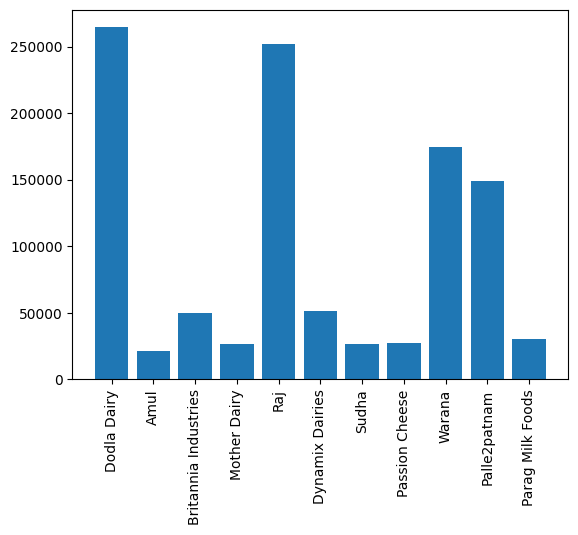

In [35]:
plt.bar(df["Brand"].unique(), df.groupby("Brand")["Quantity Sold (liters/kg)"].sum() )
plt.xticks(rotation=90)

In [39]:
x = df.groupby("Product Name")["Quantity Sold (liters/kg)"].max()
x 

Product Name
Butter        912
Buttermilk    945
Cheese        949
Curd          924
Ghee          956
Ice Cream     930
Lassi         960
Milk          940
Paneer        949
Yogurt        928
Name: Quantity Sold (liters/kg), dtype: int64

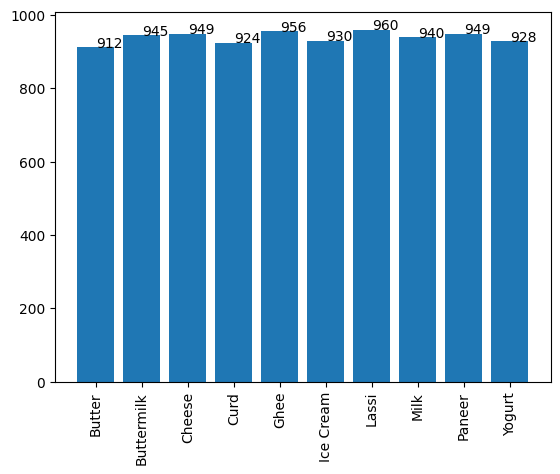

In [40]:
plt.bar(x.index, x.values)
plt.xticks(rotation=90)
for i in range(10):
    plt.text(x.index[i], x.values[i], str(x.values[i]))
plt.show()

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Land Area (acres)     4325 non-null   float64
 1   Number of Cows              4325 non-null   int64  
 2   Farm Size                   4325 non-null   object 
 3   Date                        4325 non-null   object 
 4   Product ID                  4325 non-null   int64  
 5   Product Name                4325 non-null   object 
 6   Brand                       4325 non-null   object 
 7   Quantity (liters/kg)        4325 non-null   float64
 8   Price per Unit              4325 non-null   float64
 9   Total Value                 4325 non-null   float64
 10  Shelf Life (days)           4325 non-null   int64  
 11  Storage Condition           4325 non-null   object 
 12  Quantity Sold (liters/kg)   4325 non-null   int64  
 13  Price per Unit (sold)       4325 

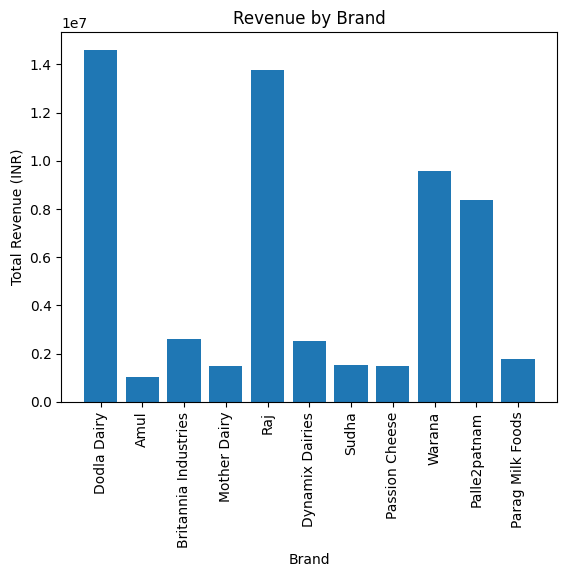

In [53]:
#Total revenue by brand name
plt.bar(df["Brand"].unique(), df.groupby("Brand")["Approx. Total Revenue(INR)"].sum())
plt.xticks(rotation=90)
plt.xlabel("Brand")
plt.ylabel("Total Revenue (INR)")
plt.title("Revenue by Brand")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Dodla Dairy'),
  Text(1, 0, 'Amul'),
  Text(2, 0, 'Britannia Industries'),
  Text(3, 0, 'Mother Dairy'),
  Text(4, 0, 'Raj'),
  Text(5, 0, 'Dynamix Dairies'),
  Text(6, 0, 'Sudha'),
  Text(7, 0, 'Passion Cheese'),
  Text(8, 0, 'Warana'),
  Text(9, 0, 'Palle2patnam'),
  Text(10, 0, 'Parag Milk Foods')])

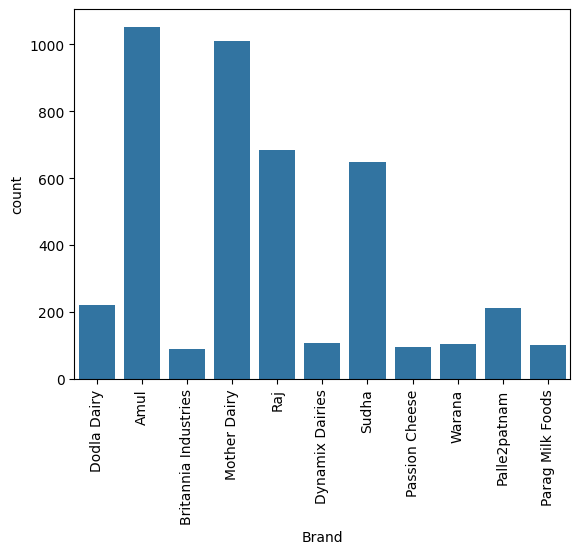

In [55]:
sns.countplot(data=df, x="Brand")
plt.xticks(rotation=90)

In [56]:
df["Sales Channel"].unique()

array(['Wholesale', 'Online', 'Retail'], dtype=object)

<Axes: xlabel='Sales Channel', ylabel='Approx. Total Revenue(INR)'>

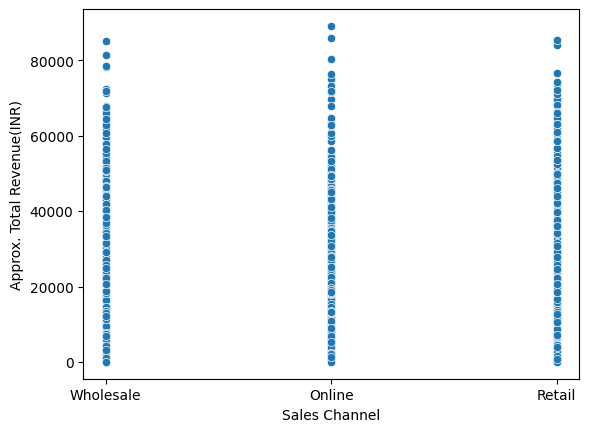

In [57]:
#Approximate Total Revenu by Sales Channel
sns.scatterplot(data=df, x="Sales Channel", y="Approx. Total Revenue(INR)")

In [58]:
df2 = df.groupby("Brand")["Approx. Total Revenue(INR)"].max().iloc[:6]

Text(0.5, 1.0, 'Revenue Distribution by Brand')

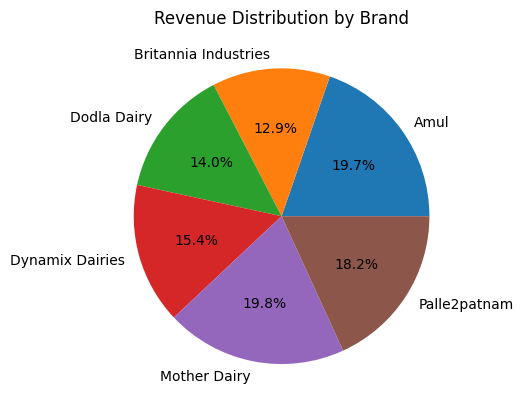

In [60]:
plt.pie(df2.values, labels=df2.index, autopct="%1.1f%%")
plt.title("Revenue Distribution by Brand")

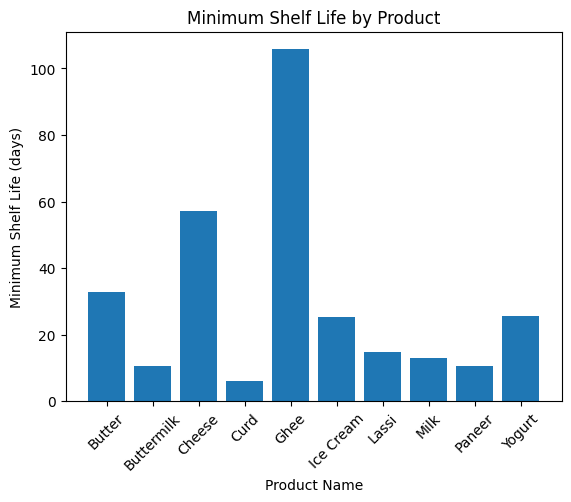

In [63]:
#Which product has minimum shelf life
df.groupby("Product Name")["Shelf Life (days)"].mean()
plt.bar(sorted(df["Product Name"].unique()), df.groupby("Product Name")["Shelf Life (days)"].mean())
plt.xlabel("Product Name")
plt.ylabel("Minimum Shelf Life (days)")
plt.title("Minimum Shelf Life by Product")
plt.xticks(rotation=45)
plt.show()